# ForestWatch Papua — Optimalisasi Dataset (Subsampling Kelas Dominan)

Notebook ini **tidak memodifikasi file patch asli**. Tujuannya:
1. Scan distribusi piksel per kelas dari seluruh patch training
2. Subsample patch yang didominasi **Perairan** dan **Hutan** agar dataset lebih seimbang
3. Tampilkan EDA distribusi **sebelum** dan **sesudah** normalisasi (teks, tanpa grafik)
4. Simpan daftar patch terpilih ke cache untuk dipakai di notebook training

**Target pengurangan:**
| Kelas | Sebelum | Target |
|---|---|---|
| Perairan (0) | ~6.86 B px | 800 juta px |
| Hutan (1) | ~3.71 B px | 1 miliar px |
| Kelas lain | keep all | keep all |

## Bagian 0 — Setup environment (Colab / Lab / Jetson)

In [9]:
# === Bagian 0 — Setup ===
ENV = "colab"   # "colab" | "lab" | "jetson"
from pathlib import Path

DRIVE_ROOT = None
DATA_ROOT  = None

if ENV == "colab":
    import subprocess, sys, importlib
    subprocess.run(
        "cd /content && (git -C fw_repo pull -q || git clone --depth 1 "
        "https://github.com/Ridho-Dwi-Syahputra/forestwatch-model.git fw_repo)",
        shell=True, check=False,
    )
    subprocess.run("pip install -q -e /content/fw_repo[gee,gis,ml]", shell=True, check=False)
    if "/content/fw_repo/src" not in sys.path:
        sys.path.insert(0, "/content/fw_repo/src")
    for _m in [m for m in list(sys.modules) if m == "forestwatch" or m.startswith("forestwatch.")]:
        del sys.modules[_m]
    importlib.invalidate_caches()
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/Satria Data 3.0")

elif ENV == "lab":
    DRIVE_ROOT = Path("G:/My Drive/Satria Data 3.0")  # sesuaikan path Drive Desktop

elif ENV == "jetson":
    DATA_ROOT = Path("/mnt/forestwatch_dataset")
    assert DATA_ROOT.exists(), f"{DATA_ROOT} tidak ada — mount SMB share dari PC dulu."

print(f"ENV={ENV} | DRIVE_ROOT={DRIVE_ROOT} | DATA_ROOT={DATA_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ENV=colab | DRIVE_ROOT=/content/drive/MyDrive/Satria Data 3.0 | DATA_ROOT=None


In [10]:
# === Path sumber patch + load daftar file ===
import json, random
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from forestwatch.constants import N_CLASSES, CLASS_NAMES
from forestwatch.data import list_patches, split_files

if ENV == "jetson":
    BAHAN_DIR  = DATA_ROOT
    CACHE_DIR  = DATA_ROOT / "optimize_cache"
    train_files = list_patches(BAHAN_DIR / "train")
    val_files   = list_patches(BAHAN_DIR / "val")
    test_files  = list_patches(BAHAN_DIR / "test")
else:
    PATCH_DIR          = DRIVE_ROOT / "ForestWatch_Patches"
    PATCHES_TRANSFER   = DRIVE_ROOT / "ForestWatch_Patches_Transfer"
    AUGMENTED_PATCHES  = DRIVE_ROOT / "Augmented_Patches"
    PATCHES_RAJA_AMPAT = DRIVE_ROOT / "ForestWatch_Patches_RajaAmpat"   # Gag -- Tambang lokal asli
    BAHAN_DIR          = DRIVE_ROOT / "Bahan_Training_Model"
    CACHE_DIR          = BAHAN_DIR  / "optimize_cache"

    papua_files      = list_patches(PATCH_DIR)
    transfer_files   = list_patches(PATCHES_TRANSFER)
    aug_files        = list_patches(AUGMENTED_PATCHES)
    raja_ampat_files = list_patches(PATCHES_RAJA_AMPAT) if PATCHES_RAJA_AMPAT.exists() else []
    train_p, val_files, test_files = split_files(papua_files, train_ratio=0.8, val_ratio=0.1, seed=42)
    train_files = list(train_p) + list(transfer_files) + list(aug_files) + list(raja_ampat_files)
    print(f"raja_ampat_files (Gag, Tambang asli) = {len(raja_ampat_files):,} patch")

CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f"train={len(train_files):,}  val={len(val_files):,}  test={len(test_files):,}")
print(f"CLASS_NAMES: {CLASS_NAMES}")

raja_ampat_files (Gag, Tambang asli) = 144 patch
train=173,222  val=19,345  test=19,346
CLASS_NAMES: ('Perairan', 'Hutan', 'Lahan Terbuka', 'Sawit', 'Pertanian Lain', 'Tambang', 'Permukiman')


## Bagian Tambahan — Verifikasi integritas Tambang region transfer

Saat menyiapkan Raja Ampat (notebook Merauke), ditemukan: footprint global Tang & Werner
(2023) + Maus dkk. (2022) **TIDAK cover** pulau tambang kecil/baru (Gag/Kawe/Manuran,
ramai 2024-2025) -> kelas Tambang 0 piksel meski tambangnya jelas terlihat di citra.

Cell ini cek apakah masalah yang sama ada di **10 region transfer Tambang** yang sudah
dipakai di `Bahan_Training_Fix` & seluruh training notebook lain -- scan langsung dari
patch yang SUDAH ADA (tidak panggil GEE lagi), tidak menebak.

In [ ]:
# === Verifikasi: apakah region transfer Tambang punya piksel kelas 5 yang genuine? ===
# Beda dgn Gag/Kawe/Manuran (pulau kecil, tambang baru 2024-25), 10 region ini adalah
# tambang RAKSASA & LAMA (Sangatta/KPC, Morowali/IMIP, Batu Hijau, Chuquicamata,
# Escondida, dll) -- persis jenis operasi yang ditarget paper footprint global. Tapi
# kita VERIFIKASI, bukan asumsi. DUA kasus mislabel yang dicek:
#   (1) region 0 piksel Tambang  -> footprint tidak cover sama sekali (spt Raja Ampat).
#   (2) rasio Lahan Terbuka(2) / Tambang(5) TINGGI -> footprint cover sebagian saja;
#       lahan gundul tambang yang di luar poligon 'bocor' jadi Lahan Terbuka via Hansen.
#       (build_label: 3a Hansen->LahanTerbuka, lalu 3b mining footprint->Tambang MENIMPA;
#        di luar poligon footprint, piksel gundul tambang tetap Lahan Terbuka.)
import numpy as np
from collections import defaultdict

_tambang_dir = PATCHES_TRANSFER / 'tambang'
_px_tambang   = defaultdict(int)   # kelas 5
_px_lahan     = defaultdict(int)   # kelas 2
_per_region_npatch = defaultdict(int)
_per_region_npatch_with_tambang = defaultdict(int)

_files = list_patches(_tambang_dir)
assert _files, f'Tidak ada patch di {_tambang_dir} -- cek path PATCHES_TRANSFER.'

for f in _files:
    data = np.load(f)
    tile_name = str(data['tile'])              # mis. 'tambang_kaltim_sangatta_tile_00.tif'
    region = tile_name.replace('tambang_', '', 1).split('_tile')[0]
    lab = data['lab']
    n_tambang = int((lab == 5).sum())
    n_lahan   = int((lab == 2).sum())
    _px_tambang[region] += n_tambang
    _px_lahan[region]   += n_lahan
    _per_region_npatch[region] += 1
    if n_tambang > 0:
        _per_region_npatch_with_tambang[region] += 1

print(f'Total patch Tambang transfer terscan: {len(_files):,}')
print()
print(f"  {'Region':<20}{'Tambang(5)':>13}{'LahanTrbk(2)':>14}{'rasio LT/Tmb':>13}{'Patch':>7}{'berisi':>8}")
print('  ' + '-' * 73)
_zero = []        # kasus (1): 0 piksel Tambang
_curiga = []      # kasus (2): rasio LT/Tambang tinggi
RATIO_FLAG = 1.0  # ambang curiga: Lahan Terbuka > 1x Tambang di region yg HARUSNYA tambang
for region in sorted(_px_tambang, key=lambda r: -_px_tambang[r]):
    t = _px_tambang[region]
    l = _px_lahan[region]
    n = _per_region_npatch[region]
    n_ok = _per_region_npatch_with_tambang[region]
    ratio = (l / t) if t > 0 else float('inf')
    ratio_str = 'inf' if t == 0 else f'{ratio:.2f}'
    flag = ''
    if t == 0:
        flag = '  <<< 0 TAMBANG (spt Raja Ampat)'
        _zero.append(region)
    elif ratio > RATIO_FLAG:
        flag = '  <<< LT >> Tambang, cek mislabel'
        _curiga.append((region, ratio))
    print(f"  {region:<20}{t:>13,}{l:>14,}{ratio_str:>13}{n:>7,}{n_ok:>8,}{flag}")

print()
if _zero:
    print(f'KASUS (1) -- {len(_zero)} region 0 piksel Tambang: {_zero}')
    print('  -> footprint tak cover; perlu override manual ala Gag, ATAU drop region itu.')
if _curiga:
    print(f'KASUS (2) -- {len(_curiga)} region rasio LahanTerbuka/Tambang > {RATIO_FLAG}:')
    for r, ra in sorted(_curiga, key=lambda x: -x[1]):
        print(f'    {r}: {ra:.2f}x -- sebagian lahan gundul tambang mungkin terlabel Lahan Terbuka.')
    print('  -> CATATAN: sebagian wajar (lahan gundul pinggir tambang != pit). Tapi rasio')
    print('     sangat tinggi di region tambang murni = sinyal footprint cuma cover sebagian.')
if not _zero and not _curiga:
    print('OK -- semua region transfer Tambang punya kelas 5 genuine & rasio LahanTerbuka wajar.')
    print('Bahan_Training_Fix AMAN dipakai utk sinyal Tambang tanpa override tambahan.')

Total patch Tambang transfer terscan: 9,632

  Region                 Tambang(5)  LahanTrbk(2) rasio LT/Tmb  Patch  berisi
  -------------------------------------------------------------------------
  zzzz_canada_athabasca   10,043,467       374,965         0.04    324     209
  zzzz_australia_huntervalley    4,491,893       267,816         0.06    400     132
  aus_huntervalley        3,323,133       129,822         0.04    224      94
  zz_usa_powderriver      2,821,014     7,398,673         2.62  1,444     116  <<< LT >> Tambang, cek mislabel
  kaltim_sangatta         2,156,271     1,400,199         0.65    400      72
  chile_escondida         2,078,132     2,116,097         1.02     64      45  <<< LT >> Tambang, cek mislabel
  zz_kalsel_adaro         1,986,530     3,830,238         1.93    900      79  <<< LT >> Tambang, cek mislabel
  zzzz_kaltim_sangatta    1,929,303     1,055,697         0.55    400      63
  zzzz_safrica_sishen     1,628,949     1,051,381         0.65    400 

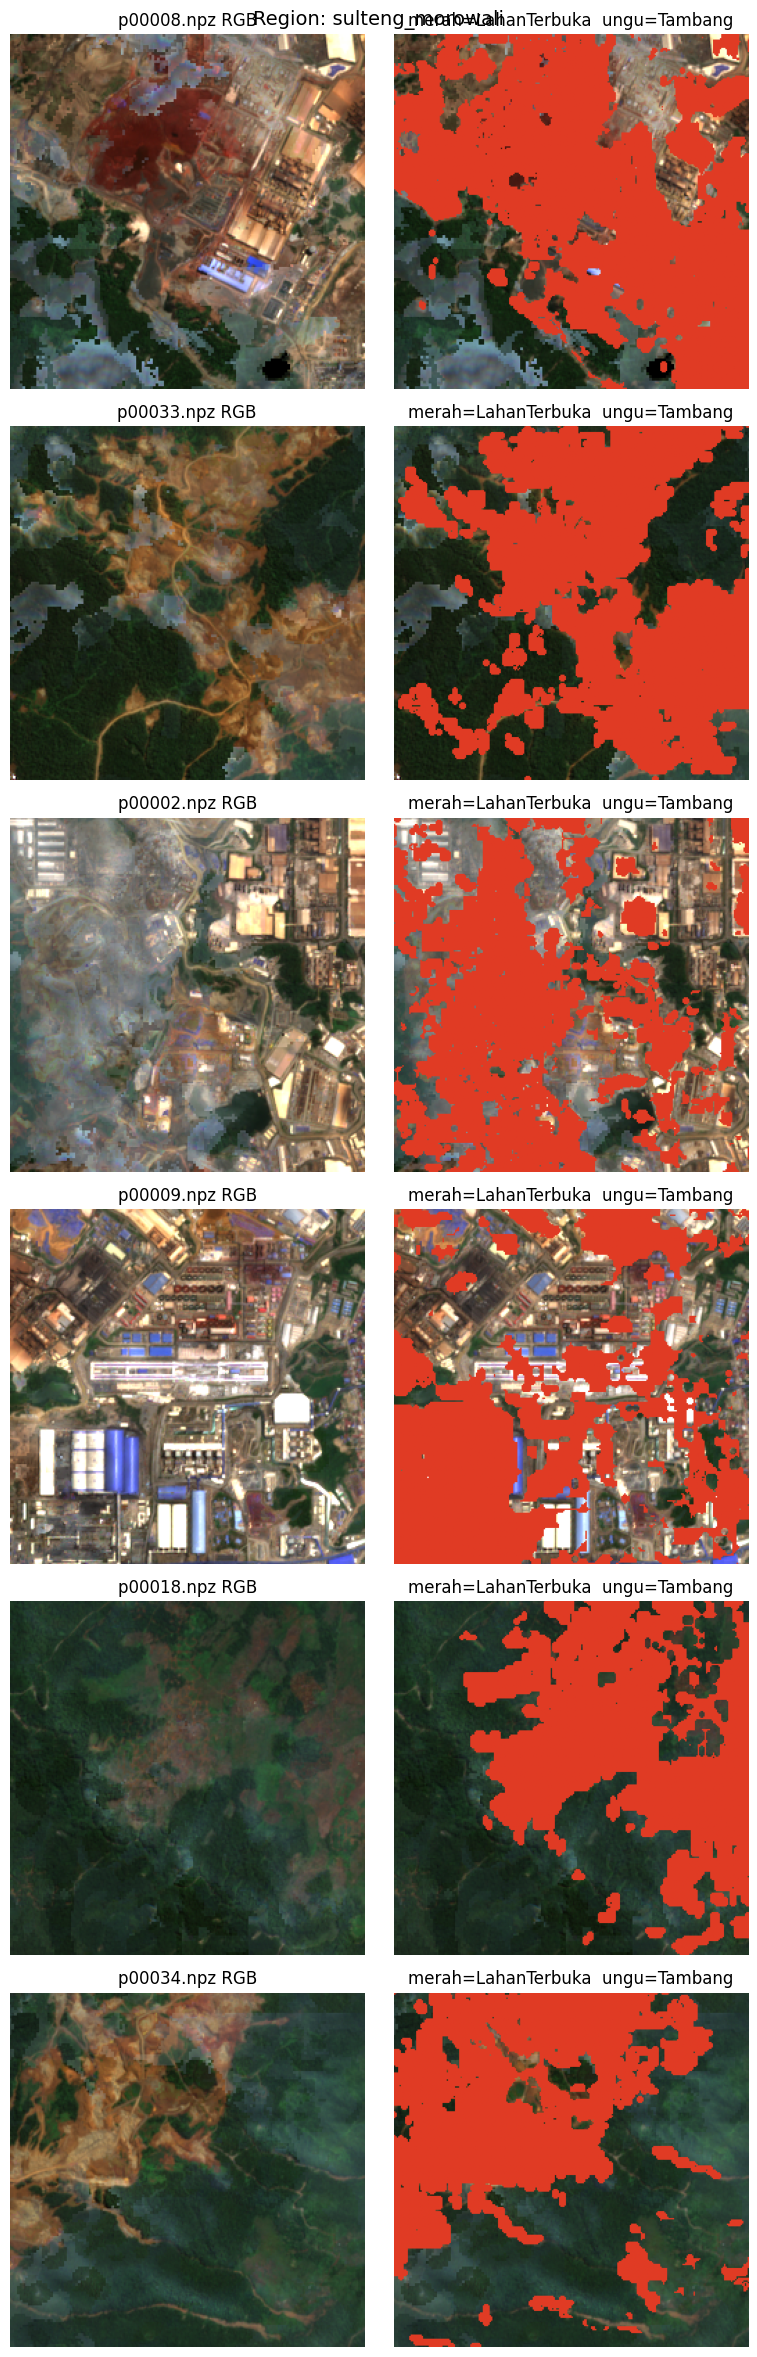

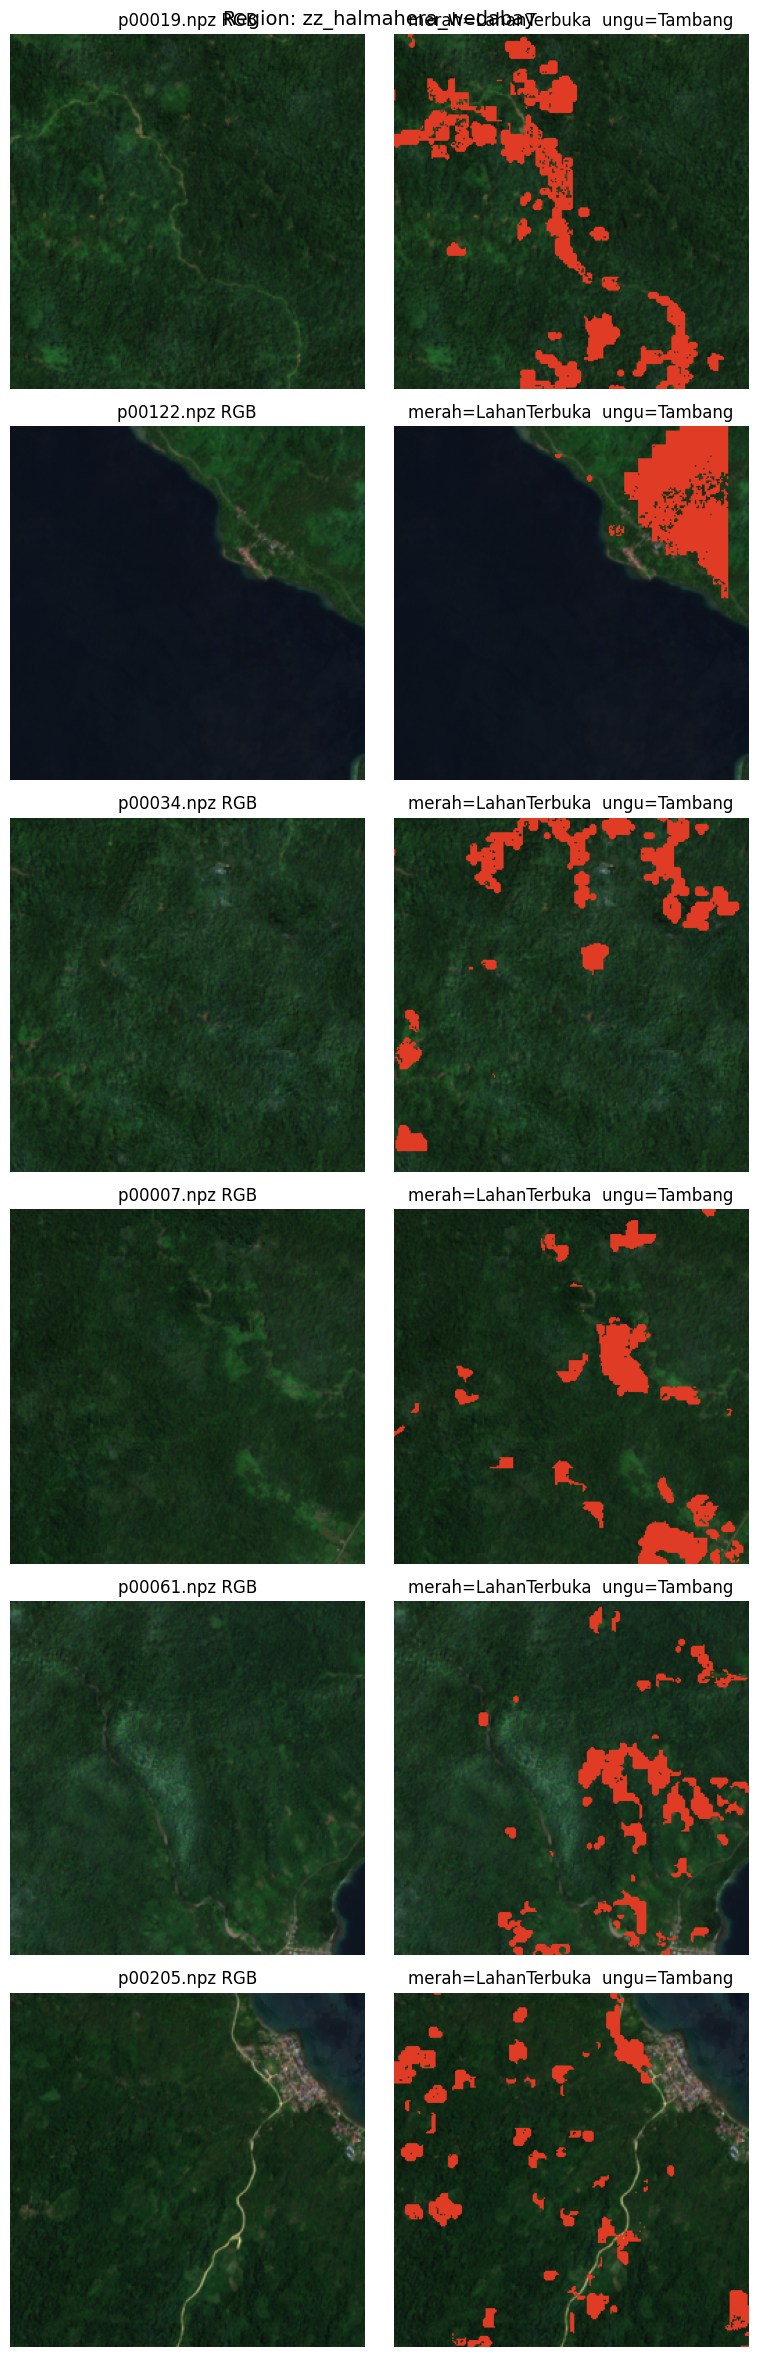


Cek manual: apakah area MERAH (Lahan Terbuka) di atas SEBENARNYA terlihat seperti
tambang aktif (tanah gundul berundak/pit/jalan tambang) di citra RGB sebelahnya?
Kalau IYA -> kandidat override (lanjut tulis fungsi override khusus region itu).
Kalau TIDAK (mis. memang sungai/awan/lahan kosong non-tambang) -> JANGAN override, biarkan apa adanya.


In [ ]:
# === Verifikasi VISUAL: Morowali & Wedabay -- cek 1-per-1 sebelum putuskan override ===
# Rasio LahanTerbuka/Tambang tinggi BUKAN bukti otomatis mislabel -- region arid/semi-arid
# (Pilbara, Powder River, dll) punya NDVI alami rendah tanpa tambang sama sekali, jadi TIDAK
# disentuh disini. Fokus 2 region paling kredibel: Wedabay (0 piksel Tambang mutlak, pola spt
# Raja Ampat) & Morowali (rasio 14,5x DI BIOMA TROPIS -- kontras vegetasi/tanah terbuka tajam,
# threshold NDVI yg sama dgn override Gag lebih bisa dipercaya disini). PURE inspeksi visual --
# TIDAK ada override/koreksi piksel ditulis di cell ini.
import matplotlib.pyplot as plt

TARGET_REGIONS_VISUAL = ['sulteng_morowali', 'zz_halmahera_wedabay']
N_SAMPLE_PER_REGION = 6   # ambil patch dgn piksel Lahan Terbuka terbanyak (paling 'mencurigakan')

def _region_of(f):
    return str(np.load(f)['tile']).replace('tambang_', '', 1).split('_tile')[0]

for region in TARGET_REGIONS_VISUAL:
    region_files = [f for f in _files if _region_of(f) == region]
    # urutkan berdasar jumlah piksel Lahan Terbuka (kelas 2) -- patch paling 'curiga' duluan
    region_files = sorted(
        region_files,
        key=lambda f: int((np.load(f)['lab'] == 2).sum()),
        reverse=True,
    )[:N_SAMPLE_PER_REGION]

    if not region_files:
        print(f'[{region}] tidak ada patch -- skip.')
        continue

    fig, axes = plt.subplots(len(region_files), 2, figsize=(8, 4 * len(region_files)))
    if len(region_files) == 1:
        axes = axes[None, :]
    fig.suptitle(f'Region: {region}', fontsize=14)
    for row, f in enumerate(region_files):
        data = np.load(f)
        img, lab = data['img'], data['lab']
        rgb = np.clip(img[[2, 1, 0]].transpose(1, 2, 0) / 0.3, 0, 1)   # stretch sama spt GEE preview (max=0.3)

        overlay = rgb.copy()
        overlay[lab == 2] = np.array([224, 59, 36]) / 255    # merah = Lahan Terbuka (lab saat ini)
        overlay[lab == 5] = np.array([142, 36, 170]) / 255   # ungu  = Tambang (lab saat ini)

        axes[row, 0].imshow(rgb); axes[row, 0].set_title(f'{f.name} RGB'); axes[row, 0].axis('off')
        axes[row, 1].imshow(overlay); axes[row, 1].set_title('merah=LahanTerbuka  ungu=Tambang'); axes[row, 1].axis('off')
    plt.tight_layout(); plt.show()

print()
print('Cek manual: apakah area MERAH (Lahan Terbuka) di atas SEBENARNYA terlihat seperti')
print('tambang aktif (tanah gundul berundak/pit/jalan tambang) di citra RGB sebelahnya?')
print('Kalau IYA -> kandidat override (lanjut tulis fungsi override khusus region itu).')
print('Kalau TIDAK (mis. memang sungai/awan/lahan kosong non-tambang) -> JANGAN override, biarkan apa adanya.')

In [12]:
# === Override Morowali: piksel Lahan Terbuka di area tambang -> Tambang ===
# Bukti visual (cell di atas, 6 patch dgn LahanTerbuka terbanyak): SEMUA menunjukkan
# infrastruktur tambang/smelter nyata (bangunan, tangki, jalan akses laterit oranye) --
# BUKAN lahan kosong biasa. Footprint Tang&Werner/Maus jelas tidak menangkap kompleks IMIP
# dgn baik (cuma 14/144 patch ada piksel Tambang). Threshold NDVI sama dgn override Gag
# (tropis, kontras tajam) -- TIDAK diterapkan ke region arid/semi-arid lain (lihat diskusi).
# Wedabay TIDAK di-override -- bukti visual region itu tidak mendukung (hutan alami + sedikit
# permukiman/jalan biasa, bukan infrastruktur tambang).
from forestwatch.utils.io import save_npz

MOROWALI_REGION = 'sulteng_morowali'
MOROWALI_NDVI_THRESHOLD = 0.25

DRY_RUN_MOROWALI = False  # WAJIB cek preview overlay (kuning) di bawah dulu sebelum set False

def _morowali_mask(img, lab):
    ndvi = (img[3].astype('float32') - img[2].astype('float32')) / (
        img[3].astype('float32') + img[2].astype('float32') + 1e-6
    )
    is_bare = ndvi < MOROWALI_NDVI_THRESHOLD
    is_lahan_terbuka = lab == 2
    is_not_water = lab != 0
    return is_bare & is_lahan_terbuka & is_not_water

morowali_files = [f for f in _files if _region_of(f) == MOROWALI_REGION]
total_changed, n_patch_changed = 0, 0
preview_rows = []   # (file, img, lab, mask, n) utk patch terdampak -> preview visual

for f in morowali_files:
    data = np.load(f)
    img, lab = data['img'], data['lab'].copy()
    mask = _morowali_mask(img, lab)
    n = int(mask.sum())
    if n > 0:
        total_changed += n
        n_patch_changed += 1
        preview_rows.append((f, img, lab, mask, n))
        if not DRY_RUN_MOROWALI:
            lab_new = lab.copy()
            lab_new[mask] = 5
            save_npz(f, img=img, lab=lab_new, tile=str(data['tile']), row=int(data['row']), col=int(data['col']))

print(f"[{'DRY RUN' if DRY_RUN_MOROWALI else 'APPLIED'}] Morowali: {n_patch_changed}/{len(morowali_files)} patch "
      f"terdampak, {total_changed:,} piksel Lahan Terbuka -> Tambang.")

if DRY_RUN_MOROWALI:
    print('Preview kuning = piksel yg AKAN diubah jadi Tambang. Cek: apakah nutupin area')
    print('tambang/industri (bukan sungai/awan/lahan biasa)? Kalau OK, set DRY_RUN_MOROWALI=False, re-run.')
    preview_rows.sort(key=lambda r: -r[4])
    top = preview_rows[:6]
    if top:
        fig, axes = plt.subplots(len(top), 2, figsize=(8, 4 * len(top)))
        if len(top) == 1:
            axes = axes[None, :]
        fig.suptitle(f'Preview override: {MOROWALI_REGION} (kuning = akan jadi Tambang)', fontsize=13)
        for row, (f, img, lab, mask, n) in enumerate(top):
            rgb = np.clip(img[[2, 1, 0]].transpose(1, 2, 0) / 0.3, 0, 1)
            overlay = rgb.copy()
            overlay[mask] = np.array([255, 235, 0]) / 255   # kuning = kandidat override
            axes[row, 0].imshow(rgb); axes[row, 0].set_title(f.name); axes[row, 0].axis('off')
            axes[row, 1].imshow(overlay); axes[row, 1].set_title(f'{n:,} px kandidat'); axes[row, 1].axis('off')
        plt.tight_layout(); plt.show()
else:
    print('SELESAI -- file .npz Morowali sudah ditimpa permanen di Drive.')
    print('Re-run cell verifikasi tabel (di atas) utk cek rasio LahanTerbuka/Tambang yg baru.')

[APPLIED] Morowali: 87/144 patch terdampak, 430,935 piksel Lahan Terbuka -> Tambang.
SELESAI -- file .npz Morowali sudah ditimpa permanen di Drive.
Re-run cell verifikasi tabel (di atas) utk cek rasio LahanTerbuka/Tambang yg baru.


In [13]:
# === Scan distribusi piksel per patch (cached — skip jika sudah ada) ===
SCAN_CACHE = CACHE_DIR / "patch_class_counts.json"

def _count_patch(path):
    data = np.load(path)
    lab  = data["lab"].flatten().astype(int)
    return np.bincount(lab, minlength=N_CLASSES).tolist()

def scan_patches(files, cache_path, max_workers=64):
    cache_p = Path(cache_path)
    dist    = {}
    if cache_p.exists():
        print(f"[cache] memuat {cache_p.name} ...")
        dist = json.loads(cache_p.read_text(encoding="utf-8"))
        missing = [f for f in files if str(f) not in dist]
        if not missing:
            print(f"  semua {len(files):,} patch sudah di cache.")
            return dist
        print(f"  {len(missing):,} patch belum ada di cache, scan sekarang ...")
        files_to_scan = missing
    else:
        files_to_scan = files

    with ThreadPoolExecutor(max_workers=max_workers) as exe:
        futures = {exe.submit(_count_patch, f): str(f) for f in files_to_scan}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Scanning patches", unit="patch"):
            dist[futures[fut]] = fut.result()

    cache_p.write_text(json.dumps(dist), encoding="utf-8")
    print(f"[cache] disimpan ke {cache_p}")
    return dist

patch_dist = scan_patches(train_files, SCAN_CACHE, max_workers=64)
print(f"\nTotal patch terscan: {len(patch_dist):,}")

Scanning patches:   0%|          | 0/173222 [00:00<?, ?patch/s]

[cache] disimpan ke /content/drive/MyDrive/Satria Data 3.0/Bahan_Training_Model/optimize_cache/patch_class_counts.json

Total patch terscan: 173,222


In [14]:
# === EDA SEBELUM normalisasi ===

def print_dist_table(files, patch_dist, label):
    total_px  = [0] * N_CLASSES
    dom_count = [0] * N_CLASSES
    for f in files:
        counts = patch_dist.get(str(f), [0] * N_CLASSES)
        for c in range(N_CLASSES):
            total_px[c] += counts[c]
        dom_count[int(np.argmax(counts))] += 1
    grand = sum(total_px)

    print(f"\n{'='*74}")
    print(f"  {label}")
    print(f"  Total patches : {len(files):,}")
    print(f"  Total piksel  : {grand:,}")
    print(f"{'='*74}")
    print(f"  {'Kelas':<18} {'Piksel':>18} {'%':>7}   {'Patch (dominan)':>15}")
    print(f"  {'-'*62}")
    for c in range(N_CLASSES):
        pct = 100 * total_px[c] / grand if grand else 0
        print(f"  {CLASS_NAMES[c]:<18} {total_px[c]:>18,} {pct:>6.1f}%   {dom_count[c]:>12,}")
    print(f"  {'-'*62}")
    print(f"  {'TOTAL':<18} {grand:>18,}  100.0%   {len(files):>12,}")
    print(f"{'='*74}")

print_dist_table(train_files, patch_dist, "SEBELUM normalisasi — Train FINAL (papua + transfer + aug)")


  SEBELUM normalisasi — Train FINAL (papua + transfer + aug)
  Total patches : 173,222
  Total piksel  : 11,352,276,992
  Kelas                          Piksel       %   Patch (dominan)
  --------------------------------------------------------------
  Perairan                6,866,705,670   60.5%        103,817
  Hutan                   3,715,215,540   32.7%         60,056
  Lahan Terbuka             138,165,681    1.2%            770
  Sawit                     126,187,535    1.1%          1,604
  Pertanian Lain            297,526,476    2.6%          3,675
  Tambang                    82,667,478    0.7%          1,371
  Permukiman                125,808,612    1.1%          1,929
  --------------------------------------------------------------
  TOTAL                  11,352,276,992  100.0%        173,222


In [15]:
# === Subsampling: kurangi patch dominan Perairan & Hutan ke target piksel ===

PIXEL_TARGETS = {
    0: 800_000_000,    # Perairan  -> 800 juta
    1: 1_000_000_000,  # Hutan     -> 1 miliar
}

def subsample_to_targets(files, patch_dist, targets, seed=42, exempt=None):
    """exempt: set file (str) yang SELALU dipertahankan, tak ikut dikelompokkan/dipangkas
    (mis. patch Raja Ampat -- sinyal Tambang lokal asli, terlalu langka utk dirisikokan
    kena subsampling acak kelompok Perairan/Hutan dominan)."""
    rng = random.Random(seed)
    exempt = exempt or set()

    kept_exempt = [f for f in files if str(f) in exempt]
    files = [f for f in files if str(f) not in exempt]
    if kept_exempt:
        print(f"  [exempt] {len(kept_exempt):,} patch dipertahankan penuh (di luar subsampling)")

    # Kelompokkan patch berdasarkan kelas dominan (kelas dengan piksel terbanyak)
    groups = {c: [] for c in range(N_CLASSES)}
    for f in files:
        counts = patch_dist.get(str(f), [0] * N_CLASSES)
        groups[int(np.argmax(counts))].append(f)

    print("Rincian per kelas:")
    selected = list(kept_exempt)
    for cls in range(N_CLASSES):
        cls_files = list(groups[cls])
        if cls not in targets:
            selected.extend(cls_files)
            print(f"  {CLASS_NAMES[cls]:<18}: keep semua {len(cls_files):,} patches")
            continue

        target_px = targets[cls]
        rng.shuffle(cls_files)
        total, kept = 0, []
        for f in cls_files:
            counts = patch_dist.get(str(f), [0] * N_CLASSES)
            total += counts[cls]
            kept.append(f)
            if total >= target_px:
                break
        selected.extend(kept)
        status = ">= target" if total >= target_px else "< target (semua dipakai)"
        print(f"  {CLASS_NAMES[cls]:<18}: {len(cls_files):,} -> {len(kept):,} patches "
              f"| {total:,} px ({status})")

    return selected

print(f"Target  Perairan : {PIXEL_TARGETS[0]:,} px")
print(f"Target  Hutan    : {PIXEL_TARGETS[1]:,} px")
print()
_raja_ampat_exempt = {str(f) for f in raja_ampat_files}
selected_train = subsample_to_targets(train_files, patch_dist, PIXEL_TARGETS, exempt=_raja_ampat_exempt)
print(f"\nRingkasan: {len(train_files):,} -> {len(selected_train):,} patches "
      f"(-{100*(1-len(selected_train)/len(train_files)):.0f}%)")

Target  Perairan : 800,000,000 px
Target  Hutan    : 1,000,000,000 px

  [exempt] 144 patch dipertahankan penuh (di luar subsampling)
Rincian per kelas:
  Perairan          : 103,680 -> 12,319 patches | 800,022,913 px (>= target)
  Hutan             : 60,049 -> 16,692 patches | 1,000,059,215 px (>= target)
  Lahan Terbuka     : keep semua 770 patches
  Sawit             : keep semua 1,604 patches
  Pertanian Lain    : keep semua 3,675 patches
  Tambang           : keep semua 1,371 patches
  Permukiman        : keep semua 1,929 patches

Ringkasan: 173,222 -> 38,504 patches (-78%)


In [16]:
# === EDA SESUDAH normalisasi + estimasi training time ===

print_dist_table(selected_train, patch_dist, "SESUDAH normalisasi — Train (patch terpilih)")

# Perbandingan ringkas
batch_size        = 8
it_per_sec_jetson = 3.5   # estimasi konservatif Jetson AGX Orin (AMP FP16)
n_iter_before = len(train_files)    / batch_size
n_iter_after  = len(selected_train) / batch_size

print(f"\n{'='*52}")
print(f"  Perbandingan sebelum vs sesudah")
print(f"{'='*52}")
print(f"  {'':25} {'Sebelum':>10}  {'Sesudah':>10}")
print(f"  {'-'*48}")
print(f"  {'Total patches':25} {len(train_files):>10,}  {len(selected_train):>10,}")
print(f"  {'Iter per epoch':25} {n_iter_before:>10,.0f}  {n_iter_after:>10,.0f}")
print(f"  {'Estimasi menit/epoch':25} {n_iter_before/it_per_sec_jetson/60:>9.0f}m  "
      f"{n_iter_after/it_per_sec_jetson/60:>9.0f}m")
print(f"  {'Estimasi 40 epoch':25} {n_iter_before/it_per_sec_jetson/3600*40:>9.1f}j  "
      f"{n_iter_after/it_per_sec_jetson/3600*40:>9.1f}j")
print(f"{'='*52}")
print(f"  (asumsi {it_per_sec_jetson} it/s @ Jetson AGX Orin, batch {batch_size})")


  SESUDAH normalisasi — Train (patch terpilih)
  Total patches : 38,504
  Total piksel  : 2,523,398,144
  Kelas                          Piksel       %   Patch (dominan)
  --------------------------------------------------------------
  Perairan                  849,706,319   33.7%         12,456
  Hutan                   1,074,194,496   42.6%         16,699
  Lahan Terbuka              84,426,139    3.3%            770
  Sawit                      92,771,705    3.7%          1,604
  Pertanian Lain            239,941,040    9.5%          3,675
  Tambang                    77,231,928    3.1%          1,371
  Permukiman                105,126,517    4.2%          1,929
  --------------------------------------------------------------
  TOTAL                   2,523,398,144  100.0%         38,504

  Perbandingan sebelum vs sesudah
                               Sebelum     Sesudah
  ------------------------------------------------
  Total patches                173,222      38,504
  Iter 

In [17]:
# === Simpan daftar patch terpilih ke cache ===
# Disimpan sebagai arcname (portable lintas env): "papua/tile_xxx/p*.npz",
# "transfer/<kelas>/tile_xxx/p*.npz", "aug/p*.npz"

def to_arcname(f):
    """Konversi path absolut ke arcname portable (prefix papua/transfer/aug)."""
    if ENV == "jetson":
        # path: DATA_ROOT/train/papua/... atau DATA_ROOT/train/transfer/...
        try:
            rel = Path(f).relative_to(BAHAN_DIR / "train")
            return rel.as_posix()
        except ValueError:
            return Path(f).name
    else:
        f = Path(f)
        for root, prefix in [
            (PATCH_DIR,          "papua"),
            (PATCHES_TRANSFER,   "transfer"),
            (AUGMENTED_PATCHES,  "aug"),
            (PATCHES_RAJA_AMPAT, "rajaampat"),
        ]:
            try:
                return f"{prefix}/{f.relative_to(root).as_posix()}"
            except ValueError:
                continue
        return f.name  # fallback

selected_arcnames = [to_arcname(f) for f in selected_train]

OUT_JSON = CACHE_DIR / "selected_train_patches.json"
OUT_JSON.write_text(json.dumps(selected_arcnames, indent=1), encoding="utf-8")
print(f"Disimpan : {OUT_JSON}")
print(f"Total    : {len(selected_arcnames):,} arcnames")
print()
print("Cara pakai di training notebook (cell 4, setelah final_train_files dibentuk):")
print("  _sel = set(json.load(open(BAHAN_DIR / 'optimize_cache' / 'selected_train_patches.json')))")
print("  final_train_files = [f for f in final_train_files")
print("                       if to_arcname(f) in _sel]")

Disimpan : /content/drive/MyDrive/Satria Data 3.0/Bahan_Training_Model/optimize_cache/selected_train_patches.json
Total    : 38,504 arcnames

Cara pakai di training notebook (cell 4, setelah final_train_files dibentuk):
  _sel = set(json.load(open(BAHAN_DIR / 'optimize_cache' / 'selected_train_patches.json')))
  final_train_files = [f for f in final_train_files
                       if to_arcname(f) in _sel]


In [18]:
# === Hitung ulang class weights dari patch terpilih ===
from forestwatch.training.metrics import median_frequency_weights

dist_fix = [0] * N_CLASSES
for f in selected_train:
    counts = patch_dist.get(str(f), [0] * N_CLASSES)
    for c in range(N_CLASSES):
        dist_fix[c] += counts[c]

class_weights_fix = median_frequency_weights(dict(enumerate(dist_fix)), n_classes=N_CLASSES)

print("Class weights BARU (dari patch terpilih):")
print(f"  {'Kelas':<18} {'Piksel':>16}   {'Weight Baru':>11}")
print(f"  {'-'*50}")
for c in range(N_CLASSES):
    print(f"  {CLASS_NAMES[c]:<18} {dist_fix[c]:>16,}   {class_weights_fix[c]:>11.4f}")


Class weights BARU (dari patch terpilih):
  Kelas                        Piksel   Weight Baru
  --------------------------------------------------
  Perairan                849,706,319        0.3000
  Hutan                 1,074,194,496        0.3000
  Lahan Terbuka            84,426,139        1.2450
  Sawit                    92,771,705        1.1330
  Pertanian Lain          239,941,040        0.4380
  Tambang                  77,231,928        1.3610
  Permukiman              105,126,517        1.0000


In [19]:
# === Bundle patch terpilih ke Bahan_Training_Fix ===
# Format SAMA dengan Bahan_Training_Model: train_part_*.tar + val.tar + test.tar
# + class_weights.json (direcalculate) + patch_sampler_weights_shared.json

from forestwatch.data.dataset import create_dataset_archives
from forestwatch.utils.io import save_json

if ENV == 'jetson':
    print("[jetson] bundling tidak didukung dari Jetson — jalankan di Colab/lab.")
else:
    BAHAN_FIX = DRIVE_ROOT / 'Bahan_Training_Fix'
    BAHAN_FIX.mkdir(parents=True, exist_ok=True)

    # Bangun arcname items dari train_files (pakai to_arcname yang sudah ada di cell 8)
    selected_set = set(selected_arcnames)

    def _all_items(files):
        """Konversi list path ke [(arcname, path)] pakai prefix papua/transfer/aug."""
        items = []
        for f in files:
            arc = to_arcname(f)
            items.append((arc, f))
        return items

    all_train_items = _all_items(train_files)
    _selected_items = [(arc, src) for arc, src in all_train_items if arc in selected_set]
    # Raja Ampat (Gag, Tambang asli) DIPISAH ke split/tar TERSENDIRI (train_rajaampat/),
    # BUKAN dicampur ke train_part01-07.tar -- supaya kalau nanti Raja Ampat berubah
    # (tambah pulau/override baru), tidak perlu re-bundle ulang 7 part train yang besar.
    ra_items_fix    = [(arc, src) for arc, src in _selected_items if arc.startswith('rajaampat/')]
    train_items_fix = [(arc, src) for arc, src in _selected_items if not arc.startswith('rajaampat/')]

    # val/test tetap utuh (holdout tidak difilter)
    val_items  = [(f"papua/{Path(f).relative_to(PATCH_DIR).as_posix()}", f) for f in val_files]
    test_items = [(f"papua/{Path(f).relative_to(PATCH_DIR).as_posix()}", f) for f in test_files]

    splits_fix = {
        'train': train_items_fix,
        'val':   val_items,
        'test':  test_items,
    }
    if ra_items_fix:
        splits_fix['train_rajaampat'] = ra_items_fix

    print(f"train  : {len(train_files):,} -> {len(train_items_fix):,} patch "
          f"(-{100*(1 - len(train_items_fix)/len(train_files)):.0f}%)")
    print(f"train_rajaampat : {len(ra_items_fix):,} patch (tar terpisah, Tambang asli Gag)")
    print(f"val    : {len(val_items):,} patch (tidak difilter)")
    print(f"test   : {len(test_items):,} patch (tidak difilter)")
    create_dataset_archives(splits_fix, BAHAN_FIX, n_train_parts=7, max_workers=64)

    save_json({'class_weights': [float(w) for w in class_weights_fix]},
              BAHAN_FIX / 'class_weights.json')
    print(f"class_weights.json disimpan ke {BAHAN_FIX}")


train  : 173,222 -> 38,360 patch (-78%)
train_rajaampat : 144 patch (tar terpisah, Tambang asli Gag)
val    : 19,345 patch (tidak difilter)
test   : 19,346 patch (tidak difilter)


Bundling train_part01:   0%|          | 0/5480 [00:00<?, ?file/s]

Bundling train_part02:   0%|          | 0/5480 [00:00<?, ?file/s]

Bundling train_part03:   0%|          | 0/5480 [00:00<?, ?file/s]

Bundling train_part04:   0%|          | 0/5480 [00:00<?, ?file/s]

Bundling train_part05:   0%|          | 0/5480 [00:00<?, ?file/s]

Bundling train_part06:   0%|          | 0/5480 [00:00<?, ?file/s]

Bundling train_part07:   0%|          | 0/5480 [00:00<?, ?file/s]

Bundling train_rajaampat_part01:   0%|          | 0/144 [00:00<?, ?file/s]

class_weights.json disimpan ke /content/drive/MyDrive/Satria Data 3.0/Bahan_Training_Fix


In [20]:
# === Hitung sampler weights untuk Bahan_Training_Fix + summary ===
import shutil
from forestwatch.data.dataset import compute_patch_sampler_weights

if ENV == 'jetson':
    print("[jetson] skip — jalankan di Colab/lab")
else:
    # Salin selected_train_patches.json ke optimize_cache dalam Bahan_Training_Fix
    _oc = BAHAN_FIX / 'optimize_cache'
    _oc.mkdir(exist_ok=True)
    shutil.copy(OUT_JSON, _oc / OUT_JSON.name)
    print(f"selected_train_patches.json disalin ke {_oc}")

    SAMPLER_CACHE_FIX = BAHAN_FIX / 'patch_sampler_weights_shared.json'
    if SAMPLER_CACHE_FIX.exists():
        print(f"[skip] {SAMPLER_CACHE_FIX.name} sudah ada.")
    else:
        sampler_files_fix = (
            [src for _, src in train_items_fix]
            + [src for _, src in ra_items_fix]
        )
        sampler_keys_fix = (
            ["/".join((Path("train") / arc).parts[-3:]) for arc, _ in train_items_fix]
            + ["/".join((Path("train_rajaampat") / arc).parts[-3:]) for arc, _ in ra_items_fix]
        )
        compute_patch_sampler_weights(
            sampler_files_fix, class_weights_fix,
            cache_path=SAMPLER_CACHE_FIX,
            keys=sampler_keys_fix,
        )
        print(f"{SAMPLER_CACHE_FIX.name} dihitung & disimpan.")

    print(f"\nBahan_Training_Fix siap di: {BAHAN_FIX}")
    print("Isi:")
    for item in sorted(BAHAN_FIX.iterdir()):
        if item.is_file():
            sz = item.stat().st_size
            sz_str = f"{sz/1e9:.2f} GB" if sz > 1e8 else f"{sz/1e6:.1f} MB"
            print(f"  {item.name:<45} {sz_str}")
        elif item.is_dir():
            print(f"  {item.name}/")
    print("\nNotebook training otomatis memakai Bahan_Training_Fix ini (cell 5).")


selected_train_patches.json disalin ke /content/drive/MyDrive/Satria Data 3.0/Bahan_Training_Fix/optimize_cache


Sampler weights:   0%|          | 0/38504 [00:00<?, ?it/s]

patch_sampler_weights_shared.json dihitung & disimpan.

Bahan_Training_Fix siap di: /content/drive/MyDrive/Satria Data 3.0/Bahan_Training_Fix
Isi:
  class_weights.json                            0.0 MB
  optimize_cache/
  patch_sampler_weights_shared.json             1.8 MB
  test/
  train/
  train_rajaampat/
  val/

Notebook training otomatis memakai Bahan_Training_Fix ini (cell 5).
